# Summary of training data

This PR shows a `BestParameterManager` that allows us to extract the best parameters found over all methods over all depths for each graphs. This summary of the best results is further stored in a json file.

In [12]:
from qaoa_parameter_setting.utils.best_parameters import BestParameterManager

Update the summary in the database. This can take a bit of time since we need to scan each result file.

In [13]:
manager = BestParameterManager()

In [14]:
manager.add_data("data/training/random_regular")

In [15]:
manager.add_data("data/training/heavy_hex")

In [16]:
manager.add_data("data/training/line_to_full")

In [17]:
manager.add_data("data/training/erdos_renyi")

In [18]:
manager.save_summary("data/training/best_parameters_summary.json", overwrite=True)

### If data has already been saved

We simply load the summary of the data and plot it.

In [19]:
manager = BestParameterManager("data/training/best_parameters_summary.json")

In [20]:
import matplotlib.pyplot as plt

def plot_energy(instance: dict, fig=None, axis=None, label=None):
    if fig is None or axis is None:
        fig, axis = plt.subplots(1, 1)
    
    depths = sorted([int(d) for d in instance.keys()])

    axis.plot(depths, [instance[str(key)]["energy"] for key in depths], label=label)

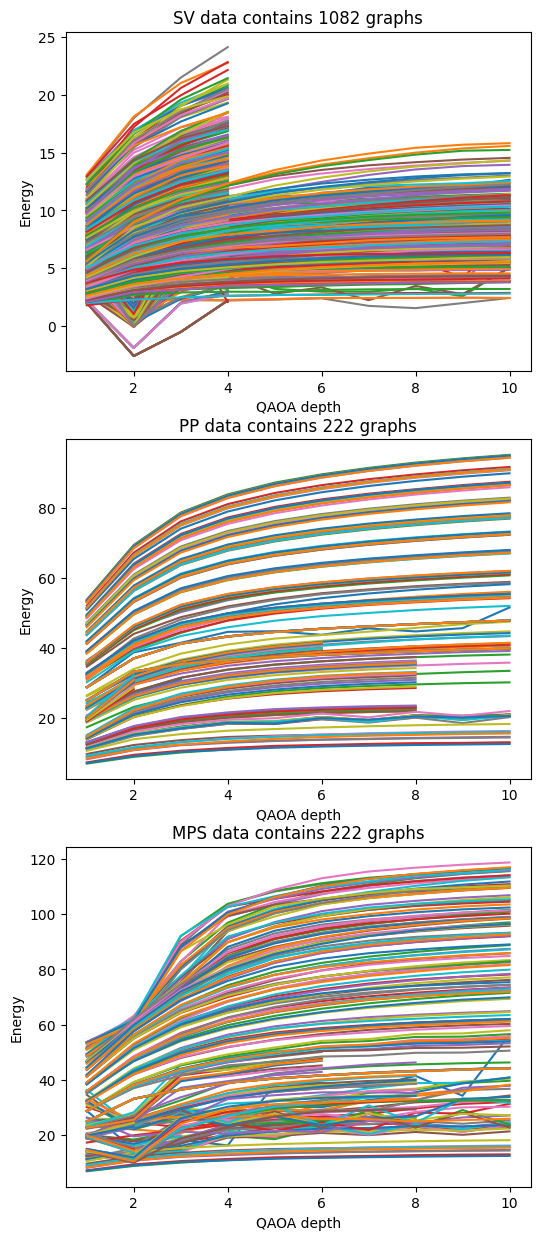

In [21]:
fig, axis = plt.subplots(3, 1, figsize=(6, 15))

for idx, method in enumerate(["SV", "PP", "MPS"]):
    instance_counter = 0
    for key, val in manager.data[method].items():
        instance_counter += 1
        plot_energy(val, fig, axis[idx], label=key)#.keys()
    
    axis[idx].set_title(f"{method} data contains {instance_counter} graphs")
    axis[idx].set_ylabel("Energy")
    axis[idx].set_xlabel("QAOA depth")
#fig.legend()

We can also filter the parameters to get those that produce monotonically increasing energies.

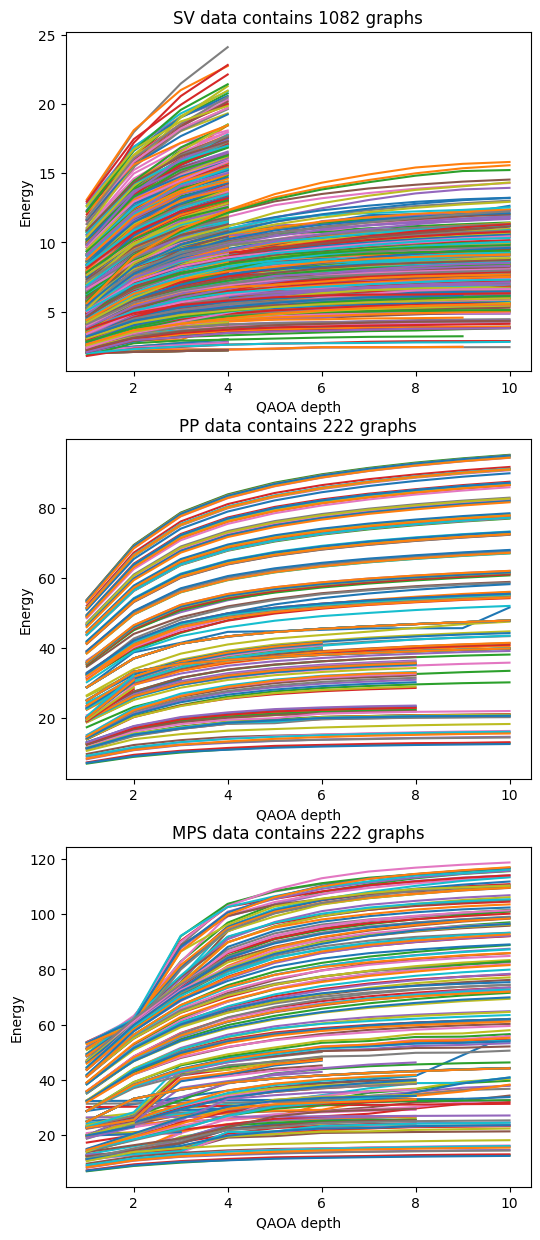

In [22]:
fig, axis = plt.subplots(3, 1, figsize=(6, 15))

monotonic_data = manager.get_monotonic_data()

for idx, method in enumerate(["SV", "PP", "MPS"]):
    instance_counter = 0
    for key, val in monotonic_data[method].items():
        instance_counter += 1
        plot_energy(val, fig, axis[idx], label=key)#.keys()
    
    axis[idx].set_title(f"{method} data contains {instance_counter} graphs")
    axis[idx].set_ylabel("Energy")
    axis[idx].set_xlabel("QAOA depth")

## Make a summary table

In [163]:
import numpy as np

from qaoa_parameter_setting.utils.instance import num_nodes

In [161]:
data = np.zeros((8, 10))
method = "SV"
all_sizes = set()

for key, val in monotonic_data[method].items():
    nnodes = num_nodes(key)
    all_sizes.add(nnodes)

min_n, max_n = min(all_sizes), max(all_sizes)
buckets = np.linspace(min_n, max_n, data.shape[0])

print(buckets)

for key, val in monotonic_data[method].items():
    nnodes = num_nodes(key)
    idx = np.digitize(nnodes, buckets)

    for depth in val:
        data[idx-1, int(depth)-1] += 1

[10. 12. 14. 16. 18. 20. 22. 24.]


[Text(0, 0, '1'),
 Text(2, 0, '3'),
 Text(4, 0, '5'),
 Text(6, 0, '7'),
 Text(8, 0, '9')]

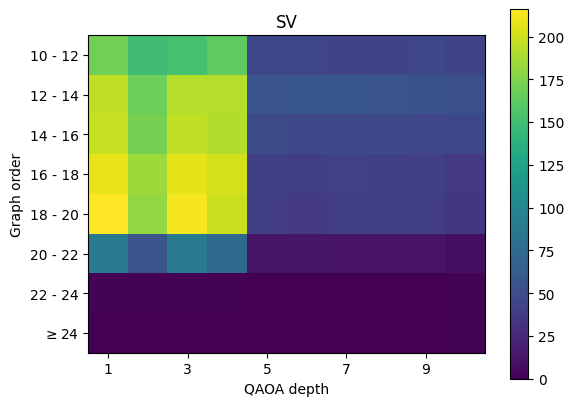

In [162]:
fig, ax = plt.subplots(1, 1)
im = ax.imshow(data)#, extent=(9.5, 10.5, 0.5, 10.5))
ax.set_title(f"{method}")
plt.colorbar(im)
ax.set_xlabel("QAOA depth")
ax.set_ylabel("Graph order")
ax.set_yticks(range(len(buckets)))
ax.set_yticklabels([f"{int(buckets[idx])} - {int(buckets[idx+1])}" for idx in range(0, len(buckets)-1)] + [r"$\geq$" + f"{int(buckets[-1])}"])
ax.set_xticks([0, 2, 4, 6, 8])
ax.set_xticklabels([1, 3, 5, 7, 9])

## Summary of the data

In [165]:
import glob

In [173]:
num_small, num_large = 0, 0

for file_name in glob.glob("instances/line_to_full/*.json"):
    nnodes = num_nodes(file_name)
    if nnodes <= 20:
        num_small += 1
    else:
        num_large += 1

print(num_small, num_large, num_small + num_large)

1450 1590 3040
